# Macro-Regime Allocation Strategy

**Group assignment sleeve:** market-implied macro regime model for dynamic allocation across `ACWI`, `AGG`, `GLD`, and `BSV`.

This notebook is built for the Algorithmic Trading group project. It follows the professor's rules:

- Investable universe is only `ACWI`, `AGG`, `GLD`, and `BSV`.
- Portfolio is always long-only and fully invested.
- Every weight is between 0% and 100%.
- Weekly allocation changes are capped at 25 percentage points in total allocation change.
- 2026 data is blocked by default to preserve the blind out-of-sample period.

The macro variables are **signals only**, not investable assets.

## Research logic

The model uses market-implied macro indicators because they update quickly and fit weekly portfolio decisions:

- **Risk stress:** VIX level and percentile.
- **Recession risk:** 10Y minus 3M Treasury yield curve slope.
- **Credit/liquidity stress:** high-yield option-adjusted spread.
- **Inflation/rates shock:** 10Y breakeven inflation and recent 10Y yield change.
- **Dollar/liquidity pressure:** broad U.S. dollar index momentum.

These pillars are converted into a single stress score and then into four regimes:

1. `Risk-On`
2. `Neutral`
3. `Defensive`
4. `Crisis`

The optimizer chooses regime thresholds and regime allocations on 2024 only. The 2025 validation is run with frozen parameters.

In [1]:
# Optional install if your local environment is missing dependencies:
# !pip install yfinance scipy seaborn

from __future__ import annotations

import os
from dataclasses import dataclass
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import requests
import yfinance as yf
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")


In [2]:
# =========================
# Project configuration
# =========================

ASSETS = ["ACWI", "AGG", "GLD", "BSV"]
SIGNAL_TICKERS = ["^VIX"]

FRED_SERIES = {
    "DGS10": "10Y Treasury Yield",
    "DGS3MO": "3M Treasury Yield",
    "BAMLH0A0HYM2": "High Yield OAS",
    "T10YIE": "10Y Breakeven Inflation",
    "DTWEXBGS": "Broad Dollar Index",
}

TEAM_ID = "TeamXX"
RISK_FREE_RATE = 0.04
MAX_TOTAL_ALLOCATION_CHANGE = 0.25
MAX_MODEL_SINGLE_ASSET_WEIGHT = 0.80

WARMUP_START = pd.Timestamp("2023-01-01")
TRAIN_START = pd.Timestamp("2024-01-01")
TRAIN_END = pd.Timestamp("2024-12-31")
VALIDATION_START = pd.Timestamp("2025-01-01")
VALIDATION_END = pd.Timestamp("2025-12-31")
BLIND_OOS_START = pd.Timestamp("2026-01-01")
LIVE_MONITOR_START = pd.Timestamp("2026-01-01")
LIVE_EVAL_START = pd.Timestamp("2026-06-01")
LIVE_EVAL_END = pd.Timestamp("2026-06-29")
SUBMISSION_DATES = pd.to_datetime([
    "2026-05-29",
    "2026-06-05",
    "2026-06-12",
    "2026-06-19",
    "2026-06-26",
])

# Keep this False until the team intentionally unlocks the blind 2026 live period.
ALLOW_2026 = True

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if ALLOW_2026:
    DATA_END = pd.Timestamp.today().normalize()
else:
    DATA_END = VALIDATION_END

print(f"Data allowed through: {DATA_END.date()}")
print(f"2026 unlocked: {ALLOW_2026}")
print("Official Friday submission dates:", [d.strftime("%Y-%m-%d") for d in SUBMISSION_DATES])

Data allowed through: 2026-05-29
2026 unlocked: True
Official Friday submission dates: ['2026-05-29', '2026-06-05', '2026-06-12', '2026-06-19', '2026-06-26']


## Canonical blocks (inlined from shared/canonical.py)

The four blocks below are inlined verbatim from `shared/canonical.py`. They define the shared KPI / turnover / submission schema all four verticals report against. Do not edit in place; edit `shared/canonical.py` and re-sync.

In [3]:
# === BEGIN canonical:constants ===
UNIVERSE = ["ACWI", "AGG", "GLD", "BSV"]
TEAM_ID = "TeamXX"
TRAIN_END = pd.Timestamp("2024-12-31")
VAL_END = pd.Timestamp("2025-12-31")
TURNOVER_CAP = 0.25
PERIODS_PER_YEAR = 52
RISK_FREE_RATE = 0.0
MAR = 0.0
MIN_PERIODS_FOR_RATIO = 24
RNG_SEED = 42

np.random.seed(RNG_SEED)
pd.set_option("display.float_format", "{:.4f}".format)
# === END canonical:constants ===

In [4]:
# === BEGIN canonical:kpis ===
def compute_kpis(
    returns: pd.Series,
    benchmark: pd.Series | None = None,
    *,
    periods_per_year: int = PERIODS_PER_YEAR,
    risk_free_rate: float = RISK_FREE_RATE,
    mar: float = MAR,
    min_periods_for_ratio: int = MIN_PERIODS_FOR_RATIO,
) -> dict:
    """Weekly KPI bank shared by every vertical.

    Sharpe uses mean excess return over sample-std (ddof=1), annualised by
    sqrt(periods_per_year). Sortino uses the textbook downside deviation:
    sqrt(mean(min(excess - mar_per_period, 0)^2)). Returns NaN for the
    ratio metrics when the sample is shorter than min_periods_for_ratio.
    """
    r = returns.dropna()
    if r.empty:
        return {}
    rf_per = risk_free_rate / periods_per_year
    mar_per = mar / periods_per_year
    ann = float(np.sqrt(periods_per_year))

    excess = r - rf_per
    mean_excess = float(excess.mean())
    vol = float(excess.std(ddof=1))

    downside = np.minimum(excess - mar_per, 0.0)
    downside_dev = float(np.sqrt(np.mean(np.square(downside))))

    equity = (1.0 + r).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    n = len(r)
    n_years = n / periods_per_year
    total_return = float(equity.iloc[-1] - 1.0)
    cagr = float(equity.iloc[-1] ** (1.0 / n_years) - 1.0) if n_years > 0 else float("nan")
    max_dd = float(drawdown.min())

    enough = n >= min_periods_for_ratio
    sharpe = (mean_excess / vol) * ann if enough and vol > 0 else float("nan")
    sortino = (mean_excess / downside_dev) * ann if enough and downside_dev > 0 else float("nan")
    calmar = cagr / abs(max_dd) if max_dd < 0 and not np.isnan(cagr) else float("nan")

    out = {
        "n_periods": int(n),
        "total_return": total_return,
        "CAGR": cagr,
        "ann_return": float(r.mean() * periods_per_year),
        "ann_vol": float(r.std(ddof=1) * ann),
        "Sharpe": float(sharpe),
        "Sortino": float(sortino),
        "max_drawdown": max_dd,
        "calmar": float(calmar),
        "hit_rate": float((r > 0).mean()),
        "best_period": float(r.max()),
        "worst_period": float(r.min()),
    }
    if benchmark is not None:
        bench = benchmark.reindex(r.index).dropna()
        active = (r - bench).dropna()
        if len(active) >= min_periods_for_ratio and active.std(ddof=1) > 0:
            out["active_sharpe_vs_bench"] = float(
                (active.mean() / active.std(ddof=1)) * ann
            )
        else:
            out["active_sharpe_vs_bench"] = float("nan")
        out["excess_ann_return"] = (
            float(active.mean() * periods_per_year) if not active.empty else float("nan")
        )
    return out
# === END canonical:kpis ===

In [5]:
# === BEGIN canonical:turnover ===
def project_to_turnover_ball(
    target: pd.Series,
    previous: pd.Series,
    *,
    cap: float = TURNOVER_CAP,
) -> pd.Series:
    """L1-ball projection of target toward previous so sum(|target-previous|) <= cap.

    Returns a Series indexed by UNIVERSE, clipped to [0,1] and renormalised to
    sum to 1. Matches the math each vertical already used independently.
    """
    target = target.reindex(UNIVERSE).astype(float)
    previous = previous.reindex(UNIVERSE).astype(float)
    delta = target - previous
    total = float(np.abs(delta).sum())
    if total <= cap + 1e-12:
        out = target.copy()
    else:
        out = previous + delta * (cap / total)
    out = out.clip(lower=0.0, upper=1.0)
    s = float(out.sum())
    return out / s if s > 0 else target
# === END canonical:turnover ===

In [6]:
# === BEGIN canonical:submission ===
def write_submission_csv(
    weights_fraction: pd.Series,
    week: "pd.Timestamp | str",
    team_id: str,
    out_dir: Path,
    *,
    vertical_tag: str | None = None,
    previous_path: Path | None = None,
    enforce_turnover: bool = True,
) -> Path:
    """Write the weekly submission CSV in the format mandated by CLAUDE.md.

    Input weights are fractions in [0,1] summing to 1. They are scaled to
    percentages, rounded to two decimals, and the residual is added to the
    largest weight so the row sums to exactly 100.00. Per-vertical draft files
    get a {team_id}_{vertical_tag}_{date}.csv name; the final team submission
    uses {team_id}_{date}.csv. Header is week,team_id,acwi,agg,gld,bsv.
    """
    week_ts = pd.Timestamp(week)
    week_str = week_ts.strftime("%Y-%m-%d")
    w = weights_fraction.reindex(UNIVERSE).astype(float) * 100.0
    w = w.round(2)
    residual = round(100.0 - float(w.sum()), 2)
    largest = w.idxmax()
    w.loc[largest] = round(float(w.loc[largest]) + residual, 2)
    if not ((w >= 0).all() and (w <= 100).all()):
        raise ValueError(f"weights out of [0,100]: {w.to_dict()}")
    if abs(float(w.sum()) - 100.0) > 1e-6:
        raise ValueError(f"weights do not sum to 100: {float(w.sum())}")
    if enforce_turnover and previous_path is not None and Path(previous_path).exists():
        prev_df = pd.read_csv(previous_path)
        prev_w = pd.Series(
            {k: float(prev_df.iloc[0][k.lower()]) for k in UNIVERSE},
        ).reindex(UNIVERSE)
        turnover_pp = float((w - prev_w).abs().sum())
        if turnover_pp - 25.0 > 1e-9:
            raise ValueError(
                f"turnover {turnover_pp:.2f}pp > 25.00pp vs {Path(previous_path).name}"
            )
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    name = (
        f"{team_id}_{vertical_tag}_{week_str}.csv"
        if vertical_tag
        else f"{team_id}_{week_str}.csv"
    )
    path = out_dir / name
    row = {
        "week": week_str,
        "team_id": team_id,
        "acwi": w["ACWI"],
        "agg": w["AGG"],
        "gld": w["GLD"],
        "bsv": w["BSV"],
    }
    pd.DataFrame([row], columns=["week", "team_id", "acwi", "agg", "gld", "bsv"]).to_csv(
        path, index=False, float_format="%.2f",
    )
    return path
# === END canonical:submission ===

In [7]:
# Canonical overwrites RISK_FREE_RATE=0.0 (was 0.04). Keep Rayane-specific
# constants that the canonical block does not define.
ASSETS = UNIVERSE  # alias used throughout the notebook
print(f"RISK_FREE_RATE now: {RISK_FREE_RATE}")


RISK_FREE_RATE now: 0.0


## Guardrails and assignment checks

These functions make the assignment rules executable. If a portfolio violates the rules, the notebook raises an error instead of silently producing an illegal allocation.

In [8]:
def assert_no_2026_data(df: pd.DataFrame | pd.Series, name: str) -> None:
    if not ALLOW_2026 and len(df) > 0:
        max_date = pd.Timestamp(df.index.max())
        if max_date >= BLIND_OOS_START:
            raise RuntimeError(
                f"{name} contains 2026 data ({max_date.date()}) while ALLOW_2026=False."
            )


def validate_weights(weights: pd.DataFrame | pd.Series, name: str = "weights") -> None:
    obj = weights.to_frame().T if isinstance(weights, pd.Series) else weights.copy()
    missing = [asset for asset in ASSETS if asset not in obj.columns]
    if missing:
        raise ValueError(f"{name} is missing required assets: {missing}")

    obj = obj[ASSETS]
    row_sums = obj.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=1e-8):
        bad = row_sums[~np.isclose(row_sums, 1.0, atol=1e-8)]
        raise ValueError(f"{name} rows must sum to 1. Bad rows: {bad.head()}")

    if (obj < -1e-10).any().any() or (obj > 1 + 1e-10).any().any():
        raise ValueError(f"{name} has weights outside [0, 1].")


def validate_turnover(weights: pd.DataFrame, name: str = "weights") -> None:
    if len(weights) <= 1:
        return
    total_change = weights[ASSETS].diff().abs().sum(axis=1).dropna()
    if (total_change > MAX_TOTAL_ALLOCATION_CHANGE + 1e-8).any():
        bad = total_change[total_change > MAX_TOTAL_ALLOCATION_CHANGE + 1e-8]
        raise ValueError(
            f"{name} violates weekly total allocation change cap. "
            f"Max found={bad.max():.4f}, cap={MAX_TOTAL_ALLOCATION_CHANGE:.4f}."
        )


def assignment_rule_report(weights: pd.DataFrame, name: str) -> pd.Series:
    return pd.Series(
        {
            "rows": len(weights),
            "sum_to_100_pct": bool(np.allclose(weights[ASSETS].sum(axis=1), 1.0, atol=1e-8)),
            "long_only": bool((weights[ASSETS] >= -1e-10).all().all()),
            "max_asset_weight": float(weights[ASSETS].max().max()),
            "max_total_weekly_change": float(weights[ASSETS].diff().abs().sum(axis=1).max()),
        },
        name=name,
    )

## Data loading

The ETF prices and VIX are loaded from Yahoo Finance. Macro series are loaded from FRED.

The data loader requests 2023 as warm-up so rolling features at the start of 2024 are not artificially missing. Optimization still scores only 2024, and validation scores only 2025.

In [9]:
REPO_ROOT_PATH = Path.cwd().parent if Path.cwd().name == "rayane-macro" else Path.cwd()
SHARED_DATA_DIR = REPO_ROOT_PATH / "data"
SHARED_DATA_DIR.mkdir(exist_ok=True)


def _load_env_file() -> None:
    env_path = REPO_ROOT_PATH / ".env"
    if not env_path.exists():
        return
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        os.environ.setdefault(key.strip(), value.strip())


_load_env_file()
FRED_API_KEY = os.environ.get("FRED_API_KEY")


def _load_fred_series(series_id: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.Series:
    """Read FRED series from on-disk cache (canonical Jan loader format); fetch+cache if missing."""
    cache = SHARED_DATA_DIR / f"{series_id}.csv"
    if cache.exists():
        df = pd.read_csv(cache, index_col="date", parse_dates=["date"])
        return df[series_id].loc[str(start.date()):str(end.date())]
    if not FRED_API_KEY:
        raise RuntimeError(
            f"FRED_API_KEY not set and no cache for {series_id} at {cache}. "
            f"Add it to {REPO_ROOT_PATH / '.env'}."
        )
    params = {"series_id": series_id, "api_key": FRED_API_KEY, "file_type": "json"}
    r = requests.get("https://api.stlouisfed.org/fred/series/observations",
                     params=params, timeout=30)
    r.raise_for_status()
    obs = pd.DataFrame(r.json()["observations"])
    obs["date"] = pd.to_datetime(obs["date"])
    obs["value"] = pd.to_numeric(obs["value"], errors="coerce")
    df = obs.set_index("date")[["value"]].rename(columns={"value": series_id})
    df.to_csv(cache)
    return df[series_id].loc[str(start.date()):str(end.date())]


def load_market_data(start: pd.Timestamp = WARMUP_START, end: pd.Timestamp = DATA_END):
    if not ALLOW_2026 and end >= BLIND_OOS_START:
        raise RuntimeError("Requested 2026 data while ALLOW_2026=False.")

    yf_end = (end + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    tickers = ASSETS + SIGNAL_TICKERS
    raw = yf.download(
        tickers,
        start=start.strftime("%Y-%m-%d"),
        end=yf_end,
        auto_adjust=True,
        progress=False,
    )

    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw[["Close"]].rename(columns={"Close": tickers[0]})

    prices = prices.dropna(how="all")
    assert_no_2026_data(prices, "Yahoo market data")

    fred_frames = []
    for sid in FRED_SERIES.keys():
        s = _load_fred_series(sid, start, end)
        fred_frames.append(s.rename(sid))
    fred = pd.concat(fred_frames, axis=1).sort_index().ffill()
    assert_no_2026_data(fred, "FRED macro data")

    return prices, fred


prices, fred = load_market_data()

print("Yahoo columns:", list(prices.columns))
print("FRED columns:", list(fred.columns))
print("Market data:", prices.index.min().date(), "to", prices.index.max().date())
print("FRED data:", fred.index.min().date(), "to", fred.index.max().date())


Yahoo columns: ['ACWI', 'AGG', 'BSV', 'GLD', '^VIX']
FRED columns: ['DGS10', 'DGS3MO', 'BAMLH0A0HYM2', 'T10YIE', 'DTWEXBGS']
Market data: 2023-01-03 to 2026-05-29
FRED data: 2023-01-02 to 2026-05-28


## Feature engineering

All features are scaled as stress measures between 0 and 1 using rolling percentiles:

- Higher value means more macro stress.
- Rolling percentiles reduce sensitivity to the absolute level of each indicator.
- The yield curve is inverted before ranking, so a lower/negative curve becomes higher stress.

In [10]:
def rolling_percentile(series: pd.Series, window: int = 252, min_periods: int = 60) -> pd.Series:
    def pct_rank(x):
        return pd.Series(x).rank(pct=True).iloc[-1]

    return series.rolling(window=window, min_periods=min_periods).apply(pct_rank, raw=False)


def build_macro_features(prices: pd.DataFrame, fred: pd.DataFrame) -> pd.DataFrame:
    base_index = prices.index
    fred_daily = fred.reindex(base_index).ffill()

    vix = prices["^VIX"].rename("vix")
    curve_10y_3m = (fred_daily["DGS10"] - fred_daily["DGS3MO"]).rename("curve_10y_3m")
    credit_oas = fred_daily["BAMLH0A0HYM2"].rename("credit_oas")
    breakeven_10y = fred_daily["T10YIE"].rename("breakeven_10y")
    ten_year_yield = fred_daily["DGS10"].rename("dgs10")
    dollar_index = fred_daily["DTWEXBGS"].rename("dollar_index")

    features = pd.DataFrame(index=base_index)
    features["vix"] = vix
    features["curve_10y_3m"] = curve_10y_3m
    features["credit_oas"] = credit_oas
    features["breakeven_10y"] = breakeven_10y
    features["dgs10"] = ten_year_yield
    features["dollar_index"] = dollar_index

    features["vix_stress"] = rolling_percentile(features["vix"])
    features["curve_stress"] = rolling_percentile(-features["curve_10y_3m"])
    features["credit_stress"] = rolling_percentile(features["credit_oas"])
    features["inflation_stress"] = rolling_percentile(features["breakeven_10y"])
    features["rate_shock_stress"] = rolling_percentile(features["dgs10"].diff(20))
    features["dollar_stress"] = rolling_percentile(features["dollar_index"].pct_change(60))

    features["inflation_rates_stress"] = features[["inflation_stress", "rate_shock_stress"]].mean(axis=1)

    pillar_weights = {
        "vix_stress": 0.30,
        "curve_stress": 0.25,
        "credit_stress": 0.20,
        "inflation_rates_stress": 0.15,
        "dollar_stress": 0.10,
    }
    features["macro_stress_score"] = sum(
        features[col] * weight for col, weight in pillar_weights.items()
    )

    feature_cols = list(pillar_weights.keys()) + ["macro_stress_score"]
    features = features.dropna(subset=feature_cols)
    assert_no_2026_data(features, "Macro features")
    return features


features_daily = build_macro_features(prices, fred)

weekly_features = features_daily.resample("W-FRI").last().dropna()
weekly_prices = prices[ASSETS].resample("W-FRI").last().dropna()

# A final partial week ending after DATA_END can be labeled with the next Friday
# (for example 2026-01-02 when DATA_END is 2025-12-31). Drop it while 2026 is locked.
weekly_features = weekly_features.loc[weekly_features.index <= DATA_END]
weekly_prices = weekly_prices.loc[weekly_prices.index <= DATA_END]
weekly_returns = weekly_prices.pct_change().dropna()

# Keep indexes aligned.
weekly_features = weekly_features.loc[weekly_features.index.intersection(weekly_returns.index)]
weekly_returns = weekly_returns.loc[weekly_returns.index.intersection(weekly_features.index)]

print("Weekly features:", weekly_features.index.min().date(), "to", weekly_features.index.max().date())
print("Weekly returns:", weekly_returns.index.min().date(), "to", weekly_returns.index.max().date())
weekly_features.tail()

Weekly features: 2023-08-25 to 2026-05-29
Weekly returns: 2023-08-25 to 2026-05-29


,vix,curve_10y_3m,credit_oas,breakeven_10y,dgs10,dollar_index,vix_stress,curve_stress,credit_stress,inflation_stress,rate_shock_stress,dollar_stress,inflation_rates_stress,macro_stress_score
Date,,,,,,,,,,,,,,
2026-05-01,16.9900,0.7100,2.7700,2.4800,4.3900,118.3926,0.4563,0.0159,0.1091,1.0000,0.6984,0.7103,0.8492,0.3611
2026-05-08,17.1900,0.6900,2.8100,2.4500,4.3800,118.0392,0.4821,0.0337,0.1964,0.9762,0.6726,0.8016,0.8244,0.3962
2026-05-15,18.4300,0.9000,2.8000,2.4900,4.5900,119.2825,0.6667,0.0040,0.1825,0.9960,0.9881,0.9206,0.9921,0.4784
2026-05-22,16.7000,0.8800,2.7400,2.4000,4.5600,119.2868,0.3889,0.0238,0.0655,0.8492,0.9484,0.9643,0.8988,0.3670
2026-05-29,15.2500,0.8000,2.7200,2.3900,4.4800,119.2868,0.1310,0.0397,0.0595,0.8056,0.7302,0.5794,0.7679,0.2342


## Visual 1: macro feature dashboard

This chart is useful for the presentation because it explains what the model sees before it allocates capital.

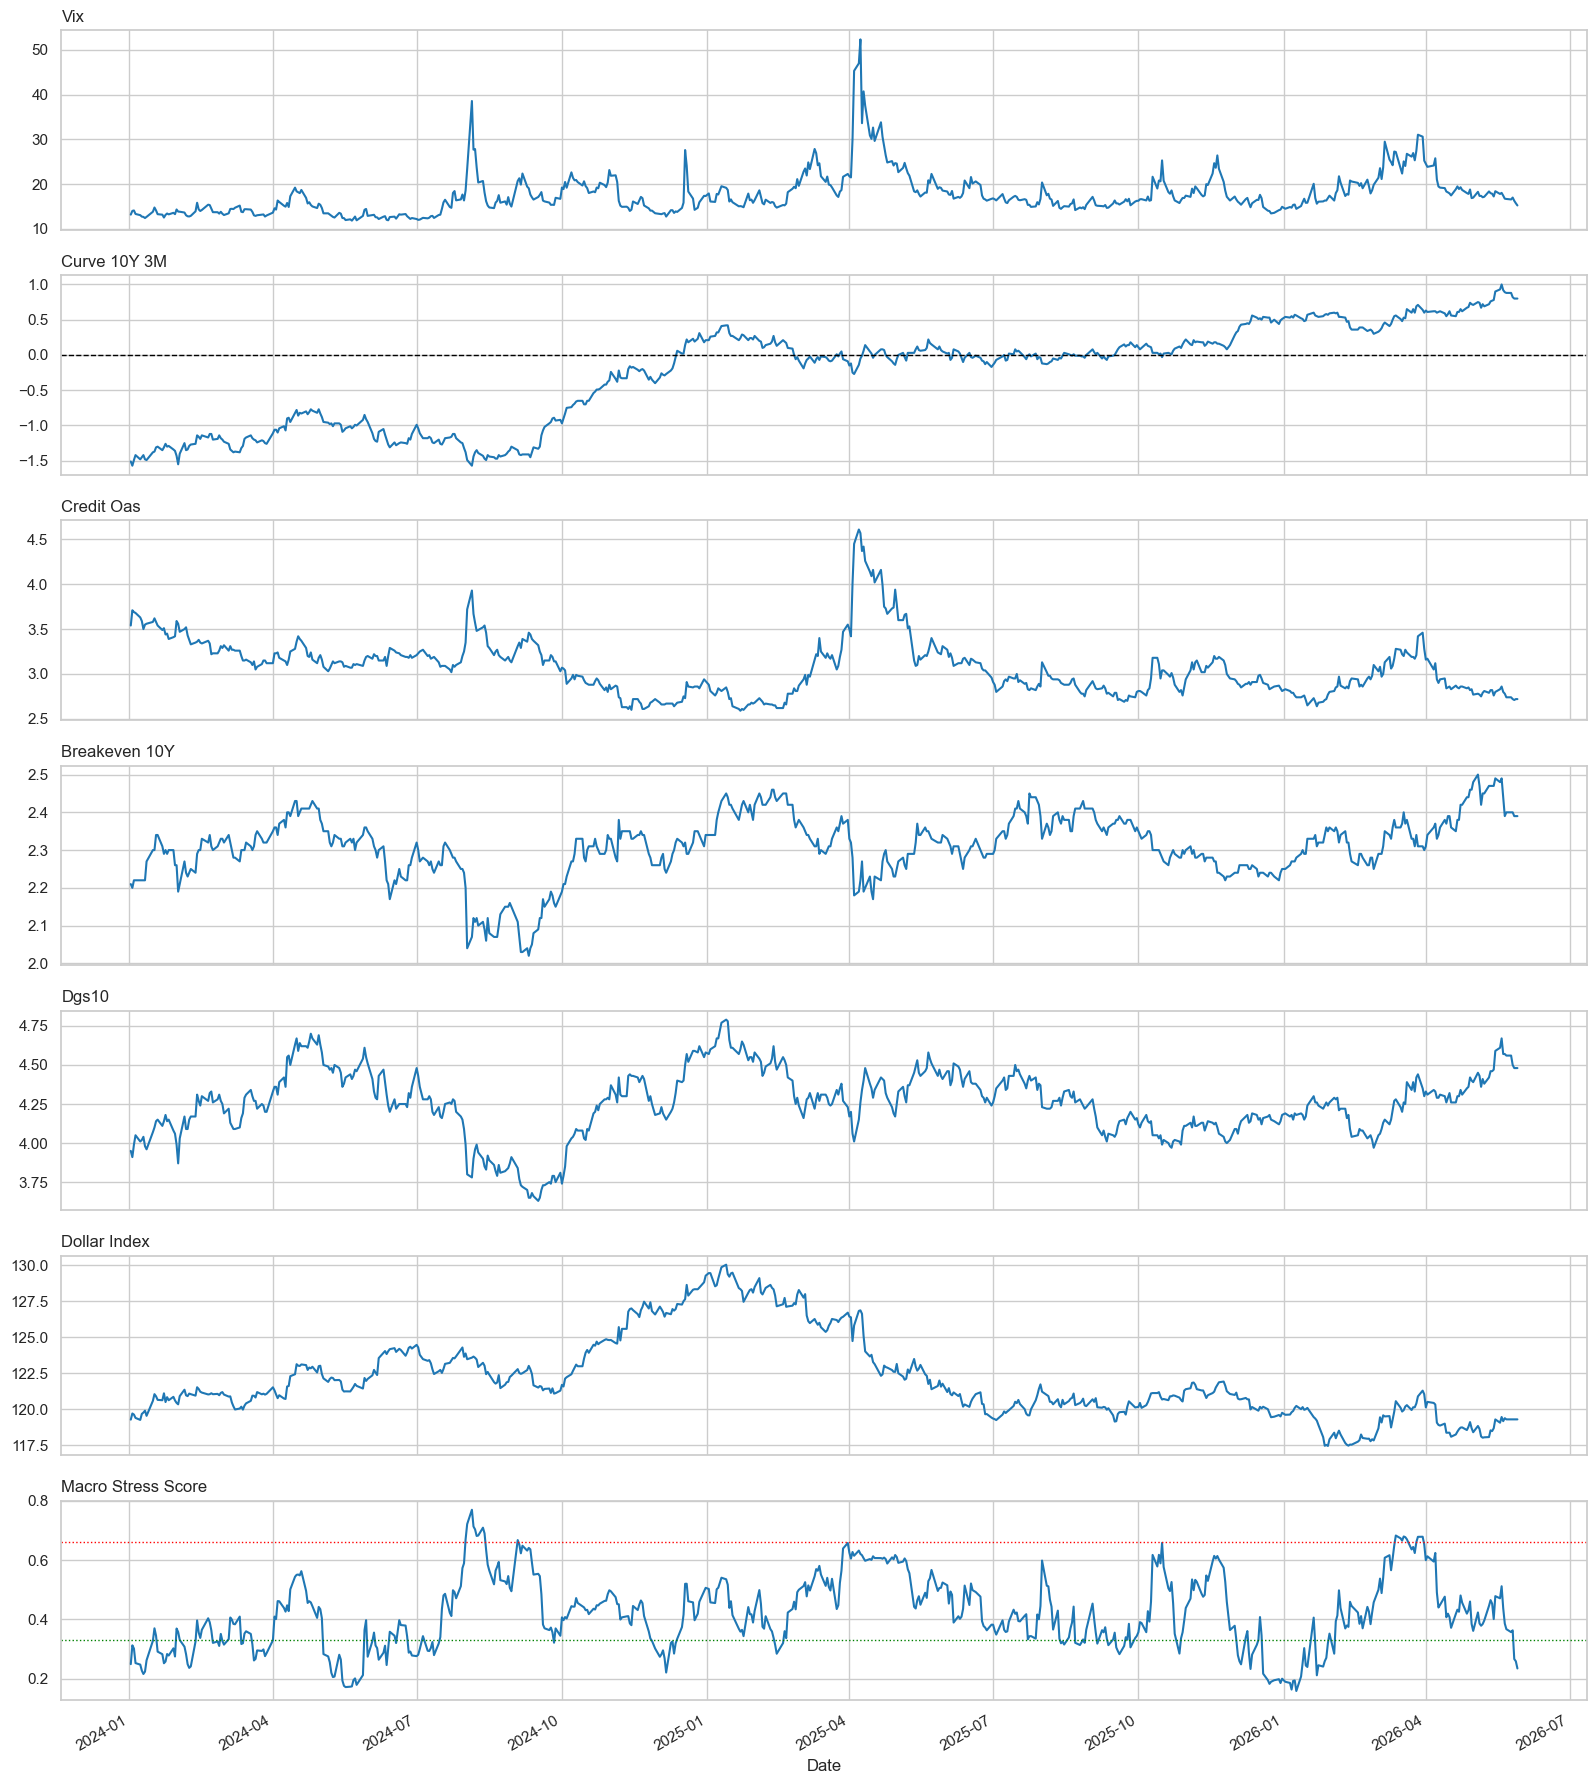

In [11]:
def chart_end_date() -> pd.Timestamp:
    return DATA_END if ALLOW_2026 else VALIDATION_END


def plot_macro_dashboard(features: pd.DataFrame, start=TRAIN_START, end=None):
    if end is None:
        end = chart_end_date()
    chart = features.loc[start:end].copy()
    cols = [
        "vix",
        "curve_10y_3m",
        "credit_oas",
        "breakeven_10y",
        "dgs10",
        "dollar_index",
        "macro_stress_score",
    ]

    fig, axes = plt.subplots(len(cols), 1, figsize=(16, 18), sharex=True)
    for ax, col in zip(axes, cols):
        chart[col].plot(ax=ax, color="#1f77b4", linewidth=1.5)
        ax.set_title(col.replace("_", " ").title(), loc="left")
        if col == "curve_10y_3m":
            ax.axhline(0, color="black", linestyle="--", linewidth=1)
        if col == "macro_stress_score":
            ax.axhline(0.33, color="green", linestyle=":", linewidth=1)
            ax.axhline(0.66, color="red", linestyle=":", linewidth=1)
    plt.tight_layout()
    return fig


plot_macro_dashboard(features_daily)
plt.show()

## Portfolio mechanics

Regime targets are allowed to change quickly, but the actual submitted portfolio must move gradually. The turnover cap below scales the move from the previous submitted allocation toward the new target if the change would exceed 25 percentage points.

In [12]:
REGIMES = ["Risk-On", "Neutral", "Defensive", "Crisis"]


def apply_turnover_cap(
    target: pd.Series,
    previous: pd.Series,
    max_change: float = MAX_TOTAL_ALLOCATION_CHANGE,
) -> pd.Series:
    """Delegate to canonical project_to_turnover_ball (same L1-ball projection)."""
    out = project_to_turnover_ball(
        pd.Series(target).reindex(ASSETS).astype(float),
        pd.Series(previous).reindex(ASSETS).astype(float),
        cap=max_change,
    )
    out.name = target.name if hasattr(target, "name") else None
    return out


def classify_regime(score: float, thresholds: np.ndarray) -> str:
    t1, t2, t3 = thresholds
    if score <= t1:
        return "Risk-On"
    if score <= t2:
        return "Neutral"
    if score <= t3:
        return "Defensive"
    return "Crisis"


def make_weight_frame(weight_matrix: np.ndarray) -> pd.DataFrame:
    weights = pd.DataFrame(weight_matrix, index=REGIMES, columns=ASSETS)
    weights = weights.div(weights.sum(axis=1), axis=0)
    return weights


def monotonic_penalty(weights: pd.DataFrame) -> float:
    acwi = weights["ACWI"].values
    defensive = weights[["AGG", "GLD", "BSV"]].sum(axis=1).values
    penalty = 0.0
    penalty += np.maximum(np.diff(acwi), 0).sum() * 10
    penalty += np.maximum(-np.diff(defensive), 0).sum() * 10
    return float(penalty)


def simulate_strategy(
    features: pd.DataFrame,
    returns: pd.DataFrame,
    thresholds: np.ndarray,
    regime_weights: pd.DataFrame,
    start: pd.Timestamp,
    end: pd.Timestamp,
    initial_weights: pd.Series | None = None,
):
    decision_features = features.loc[start:end].copy()
    returns_window = returns.loc[start:end].copy()
    decision_dates = decision_features.index.intersection(returns_window.index)

    if initial_weights is None:
        previous = pd.Series({"ACWI": 0.25, "AGG": 0.25, "GLD": 0.25, "BSV": 0.25})
    else:
        previous = initial_weights[ASSETS].astype(float).copy()
        previous = previous / previous.sum()

    actual_weights = []
    target_weights = []
    regimes = []

    for dt in decision_dates:
        score = float(decision_features.loc[dt, "macro_stress_score"])
        regime = classify_regime(score, thresholds)
        target = regime_weights.loc[regime, ASSETS].copy()
        target.name = dt
        actual = apply_turnover_cap(target, previous)
        actual.name = dt

        regimes.append(regime)
        target_weights.append(target)
        actual_weights.append(actual)
        previous = actual

    actual_df = pd.DataFrame(actual_weights)
    target_df = pd.DataFrame(target_weights)
    regime_s = pd.Series(regimes, index=decision_dates, name="regime")

    validate_weights(actual_df, "actual weights")
    validate_turnover(actual_df, "actual weights")

    # Friday weights at t are applied to the next Friday return at t+1.
    aligned_returns = returns_window.reindex(actual_df.index)
    strategy_returns = (actual_df.shift(1) * aligned_returns[ASSETS]).sum(axis=1).dropna()
    strategy_returns.name = "Macro Regime Strategy"

    return {
        "weights": actual_df,
        "targets": target_df,
        "regimes": regime_s,
        "returns": strategy_returns,
    }

## Optimization

The optimizer searches for:

- three stress-score thresholds;
- four legal regime allocations.

It uses 2024 only. The objective rewards risk-adjusted returns and penalizes drawdown, turnover, concentration, and unintuitive regime ordering.

To reduce overfitting, the optimizer uses an internal diversification rule: no regime target may allocate more than 80% to a single asset. The professor allows up to 100%, but this stricter model rule makes the allocation easier to defend.

In [13]:
@dataclass
class MacroParams:
    thresholds: np.ndarray
    regime_weights: pd.DataFrame
    train_objective: float
    train_metrics: pd.Series


def performance_metrics(returns: pd.Series, weights: pd.DataFrame | None = None, rf: float = RISK_FREE_RATE) -> pd.Series:
    """Canonical KPI bank + legacy turnover keys for objective_from_sim backwards-compat."""
    r = returns.dropna()
    legacy_nan_keys = [
        "total_return", "annualized_return", "annualized_volatility",
        "sharpe", "Sharpe", "Sortino", "max_drawdown", "CAGR",
        "calmar", "hit_rate", "n_periods",
        "avg_total_weekly_change", "avg_conventional_turnover",
    ]
    if len(r) == 0:
        return pd.Series({k: float("nan") for k in legacy_nan_keys})
    can = compute_kpis(r, risk_free_rate=rf)
    if weights is not None and len(weights) > 1:
        total_weekly_change = weights[ASSETS].diff().abs().sum(axis=1).dropna()
        avg_total_weekly_change = float(total_weekly_change.mean())
        avg_conventional_turnover = float((total_weekly_change / 2).mean())
    else:
        avg_total_weekly_change = float("nan")
        avg_conventional_turnover = float("nan")
    return pd.Series(
        {
            "total_return": can.get("total_return", float("nan")),
            "annualized_return": can.get("ann_return", float("nan")),
            "annualized_volatility": can.get("ann_vol", float("nan")),
            "sharpe": can.get("Sharpe", float("nan")),
            "Sharpe": can.get("Sharpe", float("nan")),
            "Sortino": can.get("Sortino", float("nan")),
            "CAGR": can.get("CAGR", float("nan")),
            "max_drawdown": can.get("max_drawdown", float("nan")),
            "calmar": can.get("calmar", float("nan")),
            "hit_rate": can.get("hit_rate", float("nan")),
            "n_periods": can.get("n_periods", 0),
            "avg_total_weekly_change": avg_total_weekly_change,
            "avg_conventional_turnover": avg_conventional_turnover,
        }
    )


def objective_from_sim(sim) -> float:
    rets = sim["returns"]
    weights = sim["weights"]
    metrics = performance_metrics(rets, weights)
    if metrics.isna().any():
        return -1e6

    concentration = (weights[ASSETS] ** 2).sum(axis=1).mean()
    drawdown_penalty = abs(metrics["max_drawdown"])
    turnover_penalty = metrics["avg_total_weekly_change"]

    score = (
        metrics["sharpe"]
        - 1.25 * drawdown_penalty
        - 0.40 * turnover_penalty
        - 0.20 * concentration
    )
    return float(score)


def sample_feasible_candidate(rng: np.random.Generator):
    thresholds = np.sort(rng.uniform(0.20, 0.85, size=3))
    if np.min(np.diff(thresholds)) < 0.08:
        thresholds = np.array([0.32, 0.55, 0.74]) + rng.normal(0, 0.025, 3)
        thresholds = np.sort(np.clip(thresholds, 0.20, 0.85))

    acwi = np.sort(rng.uniform(0.05, 0.80, size=4))[::-1]
    defensive_mixes = np.array(
        [
            rng.dirichlet([2.0, 1.2, 0.8]),
            rng.dirichlet([1.8, 1.6, 1.2]),
            rng.dirichlet([1.8, 2.0, 1.8]),
            rng.dirichlet([1.2, 2.4, 2.2]),
        ]
    )
    rows = []
    for i in range(4):
        remaining = 1 - acwi[i]
        rows.append(np.r_[acwi[i], defensive_mixes[i] * remaining])

    return thresholds, make_weight_frame(np.vstack(rows))


def pack_params(thresholds: np.ndarray, weights: pd.DataFrame) -> np.ndarray:
    return np.r_[thresholds, weights.loc[REGIMES, ASSETS].values.ravel()]


def unpack_params(x: np.ndarray):
    thresholds = x[:3]
    matrix = x[3:].reshape(4, 4)
    weights = make_weight_frame(matrix)
    return thresholds, weights


def optimize_macro_model(
    features: pd.DataFrame,
    returns: pd.DataFrame,
    n_random_trials: int = 350,
    random_state: int = 42,
) -> MacroParams:
    train_features = features.loc[TRAIN_START:TRAIN_END]
    train_returns = returns.loc[TRAIN_START:TRAIN_END]

    rng = np.random.default_rng(random_state)

    base_thresholds = np.array([0.32, 0.55, 0.74])
    base_weights = pd.DataFrame(
        {
            "ACWI": [0.70, 0.45, 0.25, 0.10],
            "AGG": [0.15, 0.25, 0.35, 0.25],
            "GLD": [0.10, 0.20, 0.25, 0.40],
            "BSV": [0.05, 0.10, 0.15, 0.25],
        },
        index=REGIMES,
    )

    candidates = [(base_thresholds, base_weights)]
    candidates += [sample_feasible_candidate(rng) for _ in range(n_random_trials)]

    best_score = -np.inf
    best_thresholds = None
    best_weights = None
    best_sim = None

    for thresholds, weights in candidates:
        if np.min(np.diff(thresholds)) < 0.05:
            continue
        if weights[ASSETS].max().max() > MAX_MODEL_SINGLE_ASSET_WEIGHT + 1e-12:
            continue
        sim = simulate_strategy(
            train_features,
            train_returns,
            thresholds,
            weights,
            TRAIN_START,
            TRAIN_END,
        )
        score = objective_from_sim(sim) - monotonic_penalty(weights)
        if score > best_score:
            best_score = score
            best_thresholds = thresholds
            best_weights = weights
            best_sim = sim

    def local_objective(x):
        thresholds, weights = unpack_params(x)
        if np.min(np.diff(thresholds)) < 0.05:
            return 1e5
        penalty = monotonic_penalty(weights)
        sim = simulate_strategy(
            train_features,
            train_returns,
            thresholds,
            weights,
            TRAIN_START,
            TRAIN_END,
        )
        return -(objective_from_sim(sim) - penalty)

    constraints = []
    for row in range(4):
        start = 3 + row * 4
        constraints.append({"type": "eq", "fun": lambda x, s=start: np.sum(x[s:s+4]) - 1})

    constraints += [
        {"type": "ineq", "fun": lambda x: x[1] - x[0] - 0.05},
        {"type": "ineq", "fun": lambda x: x[2] - x[1] - 0.05},
        {"type": "ineq", "fun": lambda x: x[3 + 0] - x[3 + 4]},
        {"type": "ineq", "fun": lambda x: x[3 + 4] - x[3 + 8]},
        {"type": "ineq", "fun": lambda x: x[3 + 8] - x[3 + 12]},
    ]

    bounds = (
        [(0.15, 0.90), (0.20, 0.95), (0.25, 0.99)]
        + [(0.0, MAX_MODEL_SINGLE_ASSET_WEIGHT)] * 16
    )

    result = minimize(
        local_objective,
        pack_params(best_thresholds, best_weights),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 250, "disp": False},
    )

    if result.success:
        refined_thresholds, refined_weights = unpack_params(result.x)
        refined_sim = simulate_strategy(
            train_features,
            train_returns,
            refined_thresholds,
            refined_weights,
            TRAIN_START,
            TRAIN_END,
        )
        refined_score = objective_from_sim(refined_sim) - monotonic_penalty(refined_weights)
        if refined_score >= best_score:
            best_thresholds = refined_thresholds
            best_weights = refined_weights
            best_sim = refined_sim
            best_score = refined_score

    validate_weights(best_weights, "optimized regime weights")
    train_metrics = performance_metrics(best_sim["returns"], best_sim["weights"])

    return MacroParams(
        thresholds=np.asarray(best_thresholds),
        regime_weights=best_weights,
        train_objective=float(best_score),
        train_metrics=train_metrics,
    )


# Frozen parameters from the pre-2026 research run.
# When ALLOW_2026=True, the notebook uses these constants and does not re-optimize.
# This prevents accidental live-period retuning or human-in-the-loop leakage.
FROZEN_THRESHOLDS = np.array([0.252, 0.371, 0.462])
FROZEN_REGIME_WEIGHTS = pd.DataFrame(
    {
        "ACWI": [0.5020, 0.1980, 0.1978, 0.1978],
        "AGG":  [0.2500, 0.0000, 0.0023, 0.2503],
        "GLD":  [0.0000, 0.7553, 0.0000, 0.3804],
        "BSV":  [0.2480, 0.0468, 0.7999, 0.1714],
    },
    index=REGIMES,
)
FROZEN_REGIME_WEIGHTS = FROZEN_REGIME_WEIGHTS.div(FROZEN_REGIME_WEIGHTS.sum(axis=1), axis=0)


if ALLOW_2026:
    frozen_sim = simulate_strategy(
        weekly_features,
        weekly_returns,
        FROZEN_THRESHOLDS,
        FROZEN_REGIME_WEIGHTS,
        TRAIN_START,
        TRAIN_END,
    )
    params = MacroParams(
        thresholds=FROZEN_THRESHOLDS,
        regime_weights=FROZEN_REGIME_WEIGHTS,
        train_objective=objective_from_sim(frozen_sim) - monotonic_penalty(FROZEN_REGIME_WEIGHTS),
        train_metrics=performance_metrics(frozen_sim["returns"], frozen_sim["weights"]),
    )
    print("Using frozen pre-2026 parameters. Optimization skipped because ALLOW_2026=True.")
else:
    params = optimize_macro_model(weekly_features, weekly_returns)
    print("Optimization run in research mode using 2024 only.")

print("Strategy thresholds:", np.round(params.thresholds, 3))
display((params.regime_weights * 100).round(2))
display(params.train_metrics.to_frame("2024 Train"))


Using frozen pre-2026 parameters. Optimization skipped because ALLOW_2026=True.
Strategy thresholds: [0.252 0.371 0.462]


,ACWI,AGG,GLD,BSV
Risk-On,50.2000,25.0000,0.0000,24.8000
Neutral,19.8000,0.0000,75.5200,4.6800
Defensive,19.7800,0.2300,0.0000,79.9900
Crisis,19.7800,25.0300,38.0400,17.1400


,2024 Train
total_return,0.2625
annualized_return,0.2363
annualized_volatility,0.0750
sharpe,3.1524
Sharpe,3.1524
Sortino,9.3611
CAGR,0.2625
max_drawdown,-0.0164
calmar,16.0371
hit_rate,0.5962


## Frozen-parameter validation

The next cells run the frozen 2024-trained model through 2025. No 2025 optimization occurs here.

In [14]:
BACKTEST_END = DATA_END if ALLOW_2026 else VALIDATION_END

full_sim = simulate_strategy(
    weekly_features,
    weekly_returns,
    params.thresholds,
    params.regime_weights,
    TRAIN_START,
    BACKTEST_END,
)

weights_full = full_sim["weights"]
regimes_full = full_sim["regimes"]
returns_full = full_sim["returns"]

train_returns = returns_full.loc[TRAIN_START:TRAIN_END]
validation_returns = returns_full.loc[VALIDATION_START:VALIDATION_END]
train_weights = weights_full.loc[TRAIN_START:TRAIN_END]
validation_weights = weights_full.loc[VALIDATION_START:VALIDATION_END]

metric_blocks = [
    performance_metrics(train_returns, train_weights).rename("2024 Train"),
    performance_metrics(validation_returns, validation_weights).rename("2025 Validation"),
]
rule_blocks = [
    assignment_rule_report(train_weights, "2024 Train"),
    assignment_rule_report(validation_weights, "2025 Validation"),
]

if ALLOW_2026:
    live_returns = returns_full.loc[LIVE_MONITOR_START:BACKTEST_END]
    live_weights = weights_full.loc[LIVE_MONITOR_START:BACKTEST_END]
    if len(live_weights) > 0:
        metric_blocks.append(performance_metrics(live_returns, live_weights).rename("2026 Live Monitor"))
        rule_blocks.append(assignment_rule_report(live_weights, "2026 Live Monitor"))
        print(f"2026 live monitor included through {live_weights.index.max().date()}.")
    else:
        print("ALLOW_2026=True, but no 2026 weekly rows are available yet.")

metrics = pd.concat(metric_blocks, axis=1)
rule_report = pd.concat(rule_blocks, axis=1)

display(metrics.round(4))
display(rule_report)

2026 live monitor included through 2026-05-29.


,2024 Train,2025 Validation,2026 Live Monitor
total_return,0.2625,0.3485,0.0126
annualized_return,0.2363,0.3028,0.0341
annualized_volatility,0.0750,0.0788,0.0958
sharpe,3.1524,3.8410,NaN
Sharpe,3.1524,3.8410,NaN
Sortino,9.3611,10.2127,NaN
CAGR,0.2625,0.3485,0.0302
max_drawdown,-0.0164,-0.0225,-0.0654
calmar,16.0371,15.4551,0.4611
hit_rate,0.5962,0.6731,0.6364


,2024 Train,2025 Validation,2026 Live Monitor
rows,52,52,22
sum_to_100_pct,True,True,True
long_only,True,True,True
max_asset_weight,0.7999,0.7999,0.5677
max_total_weekly_change,0.2500,0.2500,0.2500


## Benchmarks

The presentation should compare the macro strategy with simple rules from class:

- 60/40: 60% `ACWI`, 40% `AGG`.
- Permanent portfolio: 25% each in `ACWI`, `AGG`, `GLD`, `BSV`.

In [15]:
def constant_strategy_returns(returns: pd.DataFrame, weights: dict, name: str) -> pd.Series:
    w = pd.Series(weights).reindex(ASSETS).fillna(0.0)
    w = w / w.sum()
    out = (returns[ASSETS] * w).sum(axis=1)
    out.name = name
    return out


benchmark_returns = pd.concat(
    [
        returns_full.rename("Macro Regime Strategy"),
        constant_strategy_returns(weekly_returns, {"ACWI": 0.60, "AGG": 0.40}, "60/40 Portfolio"),
        constant_strategy_returns(
            weekly_returns,
            {"ACWI": 0.25, "AGG": 0.25, "GLD": 0.25, "BSV": 0.25},
            "Permanent Portfolio",
        ),
    ],
    axis=1,
).loc[TRAIN_START:BACKTEST_END].dropna()

benchmark_metrics_full = pd.concat(
    [
        performance_metrics(benchmark_returns[col]).rename(col)
        for col in benchmark_returns.columns
    ],
    axis=1,
)

print("Full backtest period (2024 → latest):")
display(benchmark_metrics_full.round(4))


# Per-period breakdown so 60/40 and the Permanent Portfolio can be compared with
# the strategy's 2024 Train / 2025 Validation / 2026 Live Monitor table above.
periods = [
    ("2024 Train", TRAIN_START, TRAIN_END),
    ("2025 Validation", VALIDATION_START, VALIDATION_END),
]
if ALLOW_2026:
    periods.append(("2026 Live Monitor", LIVE_MONITOR_START, BACKTEST_END))


def benchmark_metrics_by_period(period_returns: pd.DataFrame) -> pd.DataFrame:
    return pd.concat(
        [
            performance_metrics(period_returns[col]).rename(col)
            for col in period_returns.columns
        ],
        axis=1,
    )


per_period_tables = {}
for label, start, end in periods:
    window = benchmark_returns.loc[start:end].dropna(how="all")
    if window.empty:
        continue
    per_period_tables[label] = benchmark_metrics_by_period(window)
    print(f"\n{label} ({window.index.min().date()} → {window.index.max().date()}):")
    display(per_period_tables[label].round(4))


# Sharpe-only summary for the presentation slide.
sharpe_summary = pd.DataFrame(
    {label: table.loc["sharpe"] for label, table in per_period_tables.items()}
)
print("\nSharpe ratios by period (risk-free rate = {:.0%}):".format(RISK_FREE_RATE))
display(sharpe_summary.round(4))

Full backtest period (2024 → latest):


,Macro Regime Strategy,60/40 Portfolio,Permanent Portfolio
total_return,0.7240,0.3884,0.4543
annualized_return,0.2285,0.1395,0.1571
annualized_volatility,0.0809,0.0879,0.0677
sharpe,2.8242,1.5867,2.3205
Sharpe,2.8242,1.5867,2.3205
Sortino,5.9249,2.5273,3.9245
CAGR,0.2520,0.1450,0.1671
max_drawdown,-0.0654,-0.0779,-0.0670
calmar,3.8535,1.8609,2.4930
hit_rate,0.6349,0.6032,0.6429



2024 Train (2024-01-05 → 2024-12-27):


,Macro Regime Strategy,60/40 Portfolio,Permanent Portfolio
total_return,0.2625,0.1163,0.1230
annualized_return,0.2363,0.1133,0.1179
annualized_volatility,0.0750,0.0802,0.0605
sharpe,3.1524,1.4134,1.9483
Sharpe,3.1524,1.4134,1.9483
Sortino,9.3611,2.2958,3.5983
CAGR,0.2625,0.1163,0.1230
max_drawdown,-0.0164,-0.0398,-0.0241
calmar,16.0371,2.9232,5.1099
hit_rate,0.5962,0.5769,0.5577



2025 Validation (2025-01-03 → 2025-12-26):


,Macro Regime Strategy,60/40 Portfolio,Permanent Portfolio
total_return,0.3485,0.1649,0.2530
annualized_return,0.3028,0.1571,0.2274
annualized_volatility,0.0788,0.0928,0.0540
sharpe,3.8410,1.6922,4.2086
Sharpe,3.8410,1.6922,4.2086
Sortino,10.2127,2.6076,9.0871
CAGR,0.3485,0.1649,0.2530
max_drawdown,-0.0225,-0.0779,-0.0217
calmar,15.4551,2.1156,11.6807
hit_rate,0.6731,0.5962,0.7500



2026 Live Monitor (2026-01-02 → 2026-05-29):


,Macro Regime Strategy,60/40 Portfolio,Permanent Portfolio
total_return,0.0126,0.0677,0.0336
annualized_return,0.0341,0.1596,0.0833
annualized_volatility,0.0958,0.0969,0.1042
sharpe,NaN,NaN,NaN
Sharpe,NaN,NaN,NaN
Sortino,NaN,NaN,NaN
CAGR,0.0302,0.1675,0.0812
max_drawdown,-0.0654,-0.0626,-0.0670
calmar,0.4611,2.6741,1.2106
hit_rate,0.6364,0.6818,0.5909



Sharpe ratios by period (risk-free rate = 0%):


,2024 Train,2025 Validation,2026 Live Monitor
Macro Regime Strategy,3.1524,3.8410,NaN
60/40 Portfolio,1.4134,1.6922,NaN
Permanent Portfolio,1.9483,4.2086,NaN


## Visual 2: regime timeline

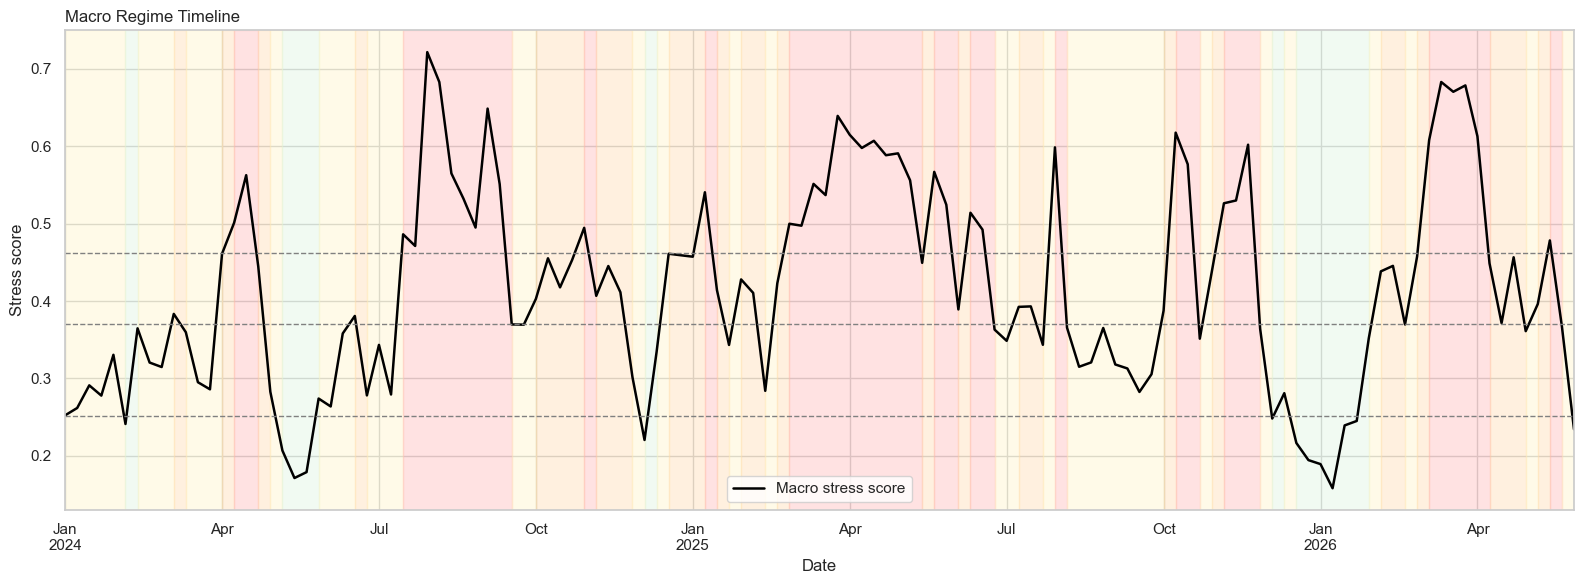

In [16]:
def plot_regime_timeline(features: pd.DataFrame, regimes: pd.Series, thresholds: np.ndarray):
    end = chart_end_date()
    chart = features.loc[TRAIN_START:end].copy()
    regime_chart = regimes.loc[TRAIN_START:end].reindex(chart.index, method="ffill")

    colors = {
        "Risk-On": "#d8f3dc",
        "Neutral": "#fff3bf",
        "Defensive": "#ffd6a5",
        "Crisis": "#ffadad",
    }

    fig, ax = plt.subplots(figsize=(16, 6))
    chart["macro_stress_score"].plot(ax=ax, color="black", linewidth=1.8, label="Macro stress score")
    for threshold in thresholds:
        ax.axhline(threshold, color="gray", linestyle="--", linewidth=1)

    # Shade weekly regimes.
    current_start = None
    current_regime = None
    for dt, regime in regime_chart.items():
        if pd.isna(regime):
            continue
        if current_regime is None:
            current_start = dt
            current_regime = regime
        elif regime != current_regime:
            ax.axvspan(current_start, dt, color=colors[current_regime], alpha=0.35)
            current_start = dt
            current_regime = regime
    if current_regime is not None:
        ax.axvspan(current_start, chart.index.max(), color=colors[current_regime], alpha=0.35)

    ax.set_title("Macro Regime Timeline", loc="left")
    ax.set_ylabel("Stress score")
    ax.legend()
    plt.tight_layout()
    return fig


plot_regime_timeline(weekly_features, regimes_full, params.thresholds)
plt.show()

## Visual 3: allocation chart

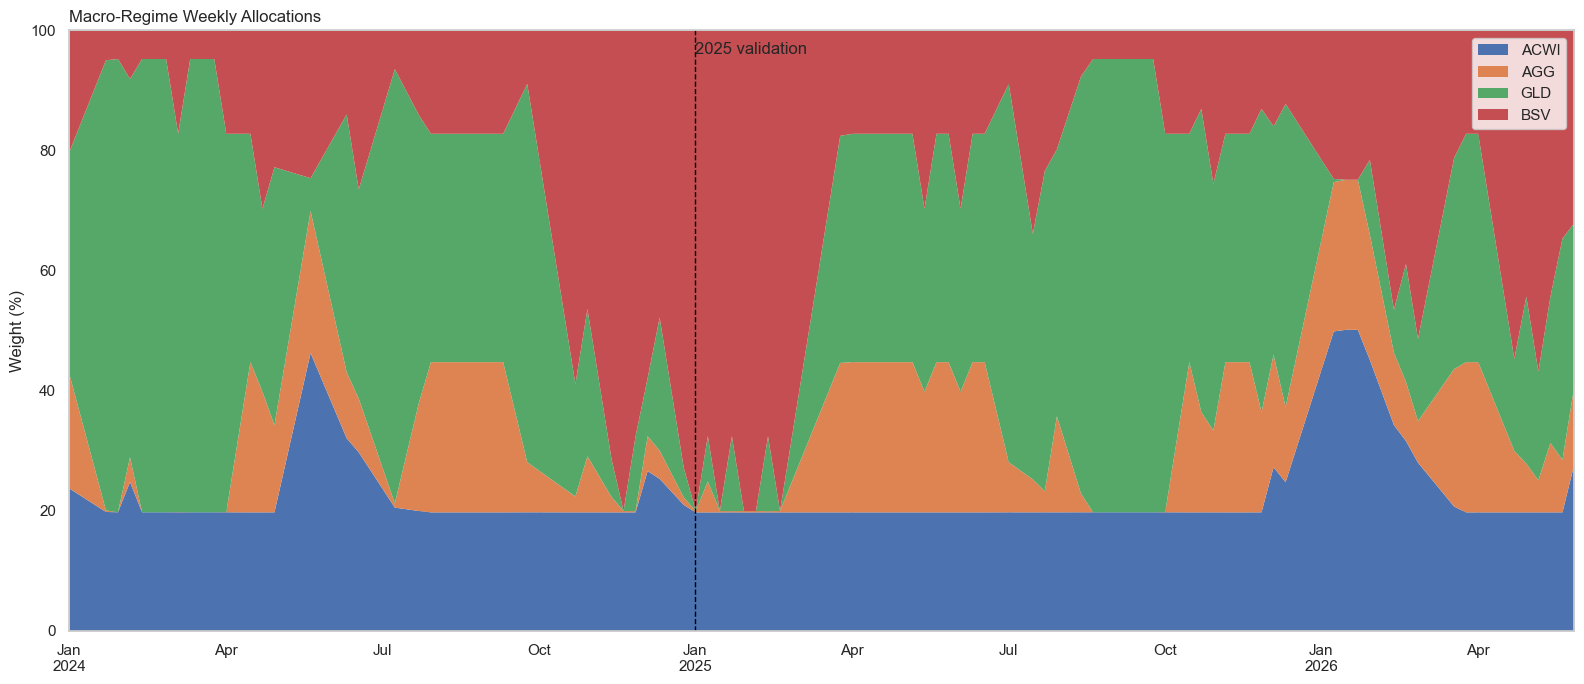

In [17]:
def plot_allocations(weights: pd.DataFrame):
    chart = weights.loc[TRAIN_START:chart_end_date(), ASSETS] * 100
    ax = chart.plot.area(figsize=(16, 7), linewidth=0)
    ax.set_title("Macro-Regime Weekly Allocations", loc="left")
    ax.set_ylabel("Weight (%)")
    ax.set_ylim(0, 100)
    ax.axvline(VALIDATION_START, color="black", linestyle="--", linewidth=1)
    ax.text(VALIDATION_START, 98, "2025 validation", va="top")
    plt.tight_layout()
    return ax


plot_allocations(weights_full)
plt.show()

## Visual 4: backtest comparison

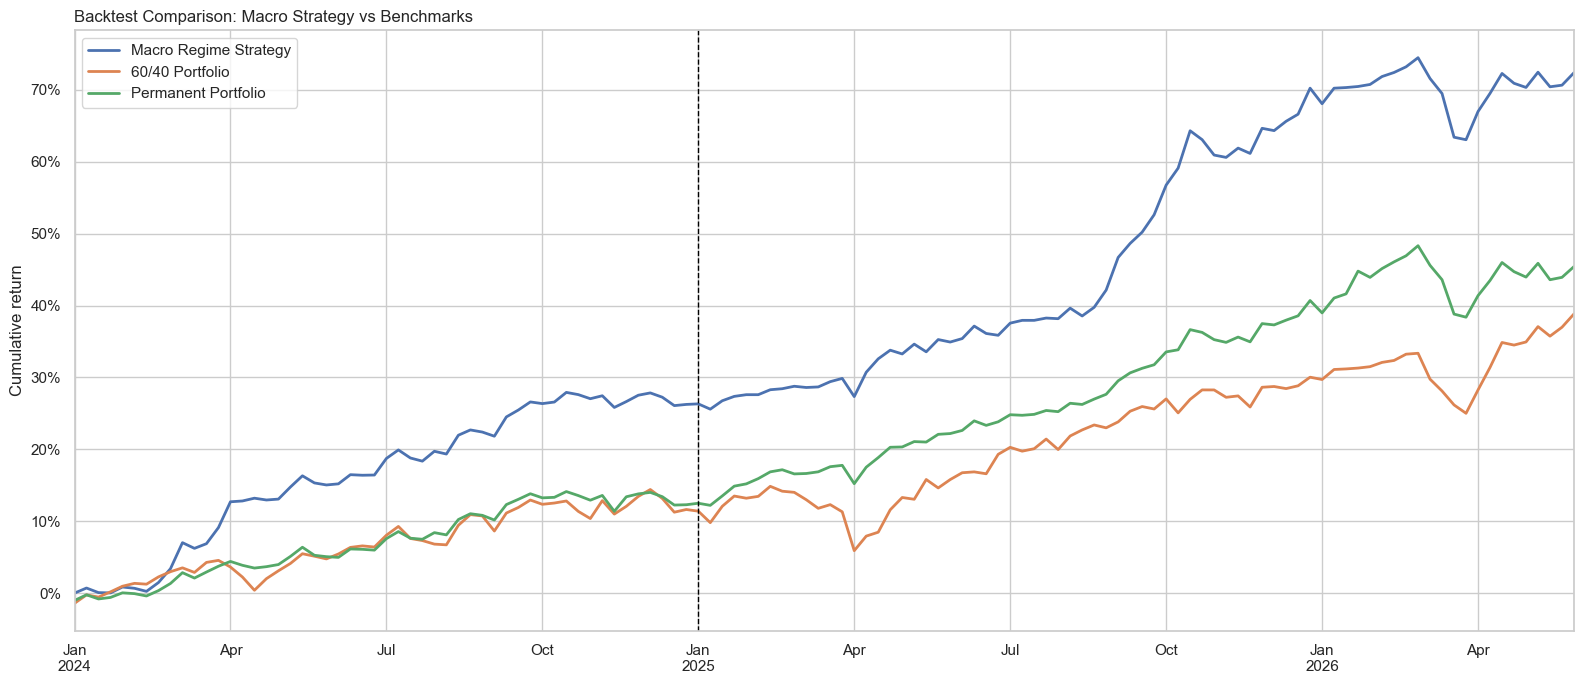

In [18]:
def plot_backtest_comparison(strategy_returns: pd.DataFrame):
    cumulative = (1 + strategy_returns).cumprod() - 1
    ax = cumulative.plot(figsize=(16, 7), linewidth=2)
    ax.axvline(VALIDATION_START, color="black", linestyle="--", linewidth=1)
    ax.set_title("Backtest Comparison: Macro Strategy vs Benchmarks", loc="left")
    ax.set_ylabel("Cumulative return")
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.tight_layout()
    return ax


plot_backtest_comparison(benchmark_returns)
plt.show()

## Professor-format CSV generator

Use this after the team unlocks 2026 live data. The function writes exactly one row with the required columns:

`week,team_id,acwi,agg,gld,bsv`

Weights are written as numeric percentages without the `%` sign.

In [19]:
def next_submission_date(as_of: str | pd.Timestamp | None = None) -> pd.Timestamp:
    if as_of is None:
        as_of = pd.Timestamp.today().normalize()
    as_of = pd.Timestamp(as_of).normalize()
    upcoming = SUBMISSION_DATES[SUBMISSION_DATES >= as_of]
    if len(upcoming) > 0:
        return pd.Timestamp(upcoming[0])
    return pd.Timestamp(SUBMISSION_DATES[-1])


def professor_csv_row(weights: pd.Series, week: str | pd.Timestamp, team_id: str = TEAM_ID) -> pd.DataFrame:
    """Build the canonical CSV row (2-decimal percentages summing to 100)."""
    week_ts = pd.Timestamp(week)
    if not ALLOW_2026 and week_ts >= BLIND_OOS_START:
        raise RuntimeError("Cannot generate a 2026 submission while ALLOW_2026=False.")
    w = pd.Series(weights).reindex(ASSETS).astype(float)
    w = w / w.sum()
    w_pct = (w * 100).round(2)
    residual = round(100.0 - float(w_pct.sum()), 2)
    largest = w_pct.idxmax()
    w_pct.loc[largest] = round(float(w_pct.loc[largest]) + residual, 2)
    return pd.DataFrame(
        [
            {
                "week": week_ts.strftime("%Y-%m-%d"),
                "team_id": team_id,
                "acwi": w_pct["ACWI"],
                "agg": w_pct["AGG"],
                "gld": w_pct["GLD"],
                "bsv": w_pct["BSV"],
            }
        ],
        columns=["week", "team_id", "acwi", "agg", "gld", "bsv"],
    )


def write_professor_csv(weights: pd.Series, week: str | pd.Timestamp, team_id: str = TEAM_ID) -> Path:
    """Delegate to canonical write_submission_csv with vertical_tag='macro'."""
    w = pd.Series(weights).reindex(ASSETS).astype(float)
    w = w / w.sum()
    return write_submission_csv(
        w,
        week,
        team_id,
        OUTPUT_DIR,
        vertical_tag="macro",
    )


print("Official submission dates:", [d.strftime("%Y-%m-%d") for d in SUBMISSION_DATES])
print("Next official submission date from today:", next_submission_date().strftime("%Y-%m-%d"))

# Validation-format example only. This is intentionally not the live 2026 submission.
latest_validation_date = validation_weights.index.max()
example_row = professor_csv_row(validation_weights.loc[latest_validation_date], latest_validation_date)
print("Validation-format example, not the live 2026 submission:")
display(example_row)


Official submission dates: ['2026-05-29', '2026-06-05', '2026-06-12', '2026-06-19', '2026-06-26']
Next official submission date from today: 2026-05-29
Validation-format example, not the live 2026 submission:


,week,team_id,acwi,agg,gld,bsv
0,2025-12-26,TeamXX,37.3700,18.6800,25.5400,18.4100


## Live weekly runner template

After the blind period is intentionally unlocked, this is the workflow for each Friday:

1. Set `ALLOW_2026 = True`.
2. Rerun data loading and feature engineering.
3. Keep the optimized 2024 parameters frozen.
4. Generate the latest target allocation.
5. Apply the 25 percentage point change cap versus the previously submitted allocation.
6. Export the professor-format CSV.

Do **not** re-optimize thresholds or allocations on 2026 live results.

In [20]:
def latest_live_allocation(
    features: pd.DataFrame,
    thresholds: np.ndarray,
    regime_weights: pd.DataFrame,
    previous_submitted_weights: pd.Series | None = None,
    run_date: str | pd.Timestamp | None = None,
) -> pd.Series:
    if run_date is None:
        run_date = pd.Timestamp.today().normalize()
    run_date = pd.Timestamp(run_date)

    available = features.loc[:run_date]
    if available.empty:
        raise ValueError("No macro features available before run_date.")

    latest_signal_date = available.index.max()
    latest_score = float(available.loc[latest_signal_date, "macro_stress_score"])
    latest_regime = classify_regime(latest_score, thresholds)
    target = regime_weights.loc[latest_regime, ASSETS].copy()

    # The first official submission has no previous submitted portfolio.
    # For later Fridays, pass the prior CSV weights as previous_submitted_weights.
    if previous_submitted_weights is None:
        actual = target / target.sum()
    else:
        actual = apply_turnover_cap(target, previous_submitted_weights)

    actual.name = latest_signal_date

    print(f"Latest signal date used: {latest_signal_date.date()}")
    print(f"Macro score: {latest_score:.3f}")
    print(f"Regime: {latest_regime}")
    if previous_submitted_weights is None:
        print("First submission mode: no previous submitted weights, so no turnover cap is applied.")
    else:
        print(f"Total allocation change: {(actual - previous_submitted_weights[ASSETS]).abs().sum():.3f}")
    return actual


def generate_live_submission(
    features: pd.DataFrame,
    thresholds: np.ndarray,
    regime_weights: pd.DataFrame,
    submission_date: str | pd.Timestamp | None = None,
    previous_submitted_weights: pd.Series | None = None,
    run_date: str | pd.Timestamp | None = None,
    team_id: str = TEAM_ID,
    write_csv: bool = False,
):
    if not ALLOW_2026:
        raise RuntimeError("Set ALLOW_2026=True to generate the live 2026 submission.")

    if submission_date is None:
        submission_date = next_submission_date()
    submission_date = pd.Timestamp(submission_date)

    if run_date is None:
        run_date = min(pd.Timestamp.today().normalize(), submission_date)

    live_weights = latest_live_allocation(
        features=features,
        thresholds=thresholds,
        regime_weights=regime_weights,
        previous_submitted_weights=previous_submitted_weights,
        run_date=run_date,
    )
    row = professor_csv_row(live_weights, submission_date, team_id=team_id)

    print(f"CSV week/submission date: {submission_date.date()}")
    if write_csv:
        output_path = write_professor_csv(live_weights, submission_date, team_id=team_id)
        print(f"Wrote CSV: {output_path}")

    return live_weights, row


if ALLOW_2026:
    # Preview for the next official Friday. On the actual Friday, rerun the notebook
    # so the latest Friday data is included. For submissions after May 29, pass the
    # prior submitted CSV weights as previous_submitted_weights.
    live_weights, live_submission_row = generate_live_submission(
        weekly_features,
        params.thresholds,
        params.regime_weights,
        submission_date=next_submission_date(),
        previous_submitted_weights=None,
        write_csv=False,
    )
    display((live_weights * 100).round(2).to_frame("live_weight_pct"))
    display(live_submission_row)
else:
    print("2026 live runner is locked. Set ALLOW_2026=True when the team is ready.")

Latest signal date used: 2026-05-29
Macro score: 0.234
Regime: Risk-On
First submission mode: no previous submitted weights, so no turnover cap is applied.
CSV week/submission date: 2026-05-29


,live_weight_pct
ACWI,50.2000
AGG,25.0000
GLD,0.0000
BSV,24.8000


,week,team_id,acwi,agg,gld,bsv
0,2026-05-29,TeamXX,50.2000,25.0000,0.0000,24.8000


## Final checklist

Run these assertions before using any allocation:

In [21]:
assert_no_2026_data(weekly_features, "weekly_features")
assert_no_2026_data(weekly_returns, "weekly_returns")
validate_weights(weights_full, "full strategy weights")
validate_turnover(weights_full, "full strategy weights")

assert set(ASSETS) == {"ACWI", "AGG", "GLD", "BSV"}
assert list(example_row.columns) == ["week", "team_id", "acwi", "agg", "gld", "bsv"]
assert len(example_row) == 1

if ALLOW_2026:
    assert list(live_submission_row.columns) == ["week", "team_id", "acwi", "agg", "gld", "bsv"]
    assert len(live_submission_row) == 1
    validate_weights(live_weights, "live submission weights")

print("All assignment checks passed.")

All assignment checks passed.


## 11. Canonical summary (orchestration parity layer)

This section exposes `get_weights(as_of_date)` matching the contract the orchestrator (Rayane himself, in his combiner role) will read from each vertical, and writes the upcoming Friday's draft submission via the canonical writer with `vertical_tag='macro'`.

In [22]:
def get_weights(as_of_date) -> pd.Series:
    """Canonical signal contract: Series indexed UNIVERSE, in [0,1], summing to 1."""
    target = pd.Timestamp(as_of_date)
    weights = latest_live_allocation(
        features=weekly_features,
        thresholds=params.thresholds,
        regime_weights=params.regime_weights,
        previous_submitted_weights=None,
        run_date=target,
    )
    w = pd.Series(weights).reindex(UNIVERSE).astype(float)
    s = float(w.sum())
    return w / s if s > 0 else w


In [23]:
canonical_records = []
for label, segment_returns, segment_weights in [
    ("TRAIN", train_returns, train_weights),
    ("VAL 2025", validation_returns, validation_weights),
]:
    canonical_records.append({
        "segment": label,
        "strategy": "Macro Regime",
        **compute_kpis(segment_returns),
    })

if ALLOW_2026 and "live_weights" in dir():
    canonical_records.append({
        "segment": "2026 YTD",
        "strategy": "Macro Regime",
        **compute_kpis(live_returns),
    })

canonical_kpis_df = pd.DataFrame(canonical_records).set_index(["segment", "strategy"])
canonical_kpis_df


,,n_periods,total_return,CAGR,ann_return,ann_vol,Sharpe,Sortino,max_drawdown,calmar,hit_rate,best_period,worst_period
segment,strategy,,,,,,,,,,,,
TRAIN,Macro Regime,52,0.2625,0.2625,0.2363,0.0750,3.1524,9.3611,-0.0164,16.0371,0.5962,0.0351,-0.0128
VAL 2025,Macro Regime,52,0.3485,0.3485,0.3028,0.0788,3.8410,10.2127,-0.0225,15.4551,0.6731,0.0327,-0.0195
2026 YTD,Macro Regime,22,0.0126,0.0302,0.0341,0.0958,NaN,NaN,-0.0654,0.4611,0.6364,0.0241,-0.0358


In [24]:
VERTICAL_ROOT = Path.cwd()
SUBMISSIONS_DIR = VERTICAL_ROOT / "submissions"
RESULTS_DIR = VERTICAL_ROOT / "results"
SUBMISSIONS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

_today = pd.Timestamp.today().normalize()
_days_to_fri = (4 - _today.weekday()) % 7
TARGET_DATE = (_today + pd.Timedelta(days=_days_to_fri)).strftime("%Y-%m-%d")
target = pd.Timestamp(TARGET_DATE)
assert target.day_name() == "Friday", f"{TARGET_DATE} is a {target.day_name()}, not a Friday"

weights_target = get_weights(target)
print(f"Weights for {TARGET_DATE}:")
print(weights_target.map(lambda x: f"{x:.4f}").to_string())
print(f"sum = {float(weights_target.sum()):.6f}")

out_path = write_submission_csv(
    weights_target,
    target,
    TEAM_ID,
    SUBMISSIONS_DIR,
    vertical_tag="macro",
)
print(f"\nwrote: {out_path}")
print(out_path.read_text())

weights_full.to_csv(RESULTS_DIR / "weekly_weights_history.csv")
canonical_kpis_df.to_csv(RESULTS_DIR / "kpis_segments.csv")
print(f"\nwrote: {RESULTS_DIR / 'weekly_weights_history.csv'}")
print(f"wrote: {RESULTS_DIR / 'kpis_segments.csv'}")


Latest signal date used: 2026-05-29
Macro score: 0.234
Regime: Risk-On
First submission mode: no previous submitted weights, so no turnover cap is applied.
Weights for 2026-05-29:
ACWI    0.5020
AGG     0.2500
GLD     0.0000
BSV     0.2480
sum = 1.000000

wrote: c:\Users\sacha\Downloads\algo-trading-group\rayane-macro\submissions\TeamXX_macro_2026-05-29.csv
week,team_id,acwi,agg,gld,bsv
2026-05-29,TeamXX,50.20,25.00,0.00,24.80


wrote: c:\Users\sacha\Downloads\algo-trading-group\rayane-macro\results\weekly_weights_history.csv
wrote: c:\Users\sacha\Downloads\algo-trading-group\rayane-macro\results\kpis_segments.csv
